
### Langkah 1: Memuat Dataset
Pada langkah pertama, kita akan memuat dataset dummy yang berisi informasi harga produk, permintaan, stok, harga persaingan, dan faktor eksternal lainnya seperti musim. Dataset ini akan digunakan untuk mengembangkan model sistem harga dinamis yang dapat membantu UMKM menyesuaikan harga secara otomatis berdasarkan kondisi pasar.


In [1]:
import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('14_sistem_harga_dinamis.xlsx')
dummy_df

,Product ID,Product Name,Base Price (IDR),Demand,Stock,Competition Price (IDR),Season,Price Adjusted (IDR)
0,1,Product A,1.717402e+06,190,334,1.999437e+06,Peak,3.658251e+06
1,2,Product A,2.652996e+06,66,64,3.922925e+06,Off-peak,2.489884e+06
2,3,Product A,2.151400e+06,300,30,1.860566e+06,Off-peak,5.394543e+05
3,4,Product D,1.111863e+06,117,98,4.180358e+06,Peak,2.565483e+06
4,5,Product D,1.156333e+06,228,49,1.608732e+06,Peak,4.805271e+06
...,...,...,...,...,...,...,...,...
95,96,Product B,1.489776e+06,497,24,3.655202e+06,Off-peak,4.277284e+06
96,97,Product D,2.632985e+06,125,23,2.893063e+06,Peak,2.971859e+06
97,98,Product B,2.613672e+06,375,353,9.312008e+05,Peak,4.740725e+06
98,99,Product B,1.521553e+06,210,221,2.817912e+06,Off-peak,7.038576e+05



### Langkah 2: Visualisasi Data
Pada langkah kedua, kita akan memvisualisasikan beberapa data terkait harga produk dan faktor-faktor yang mempengaruhi harga, seperti harga dasar produk dan harga persaingan. Visualisasi ini membantu kita untuk memahami pola dalam harga produk yang ada serta bagaimana faktor eksternal seperti permintaan dan persaingan mempengaruhi harga yang disesuaikan.


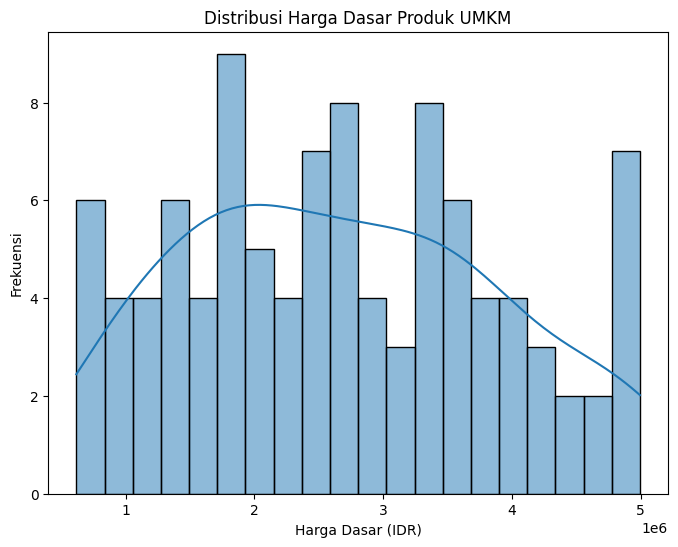

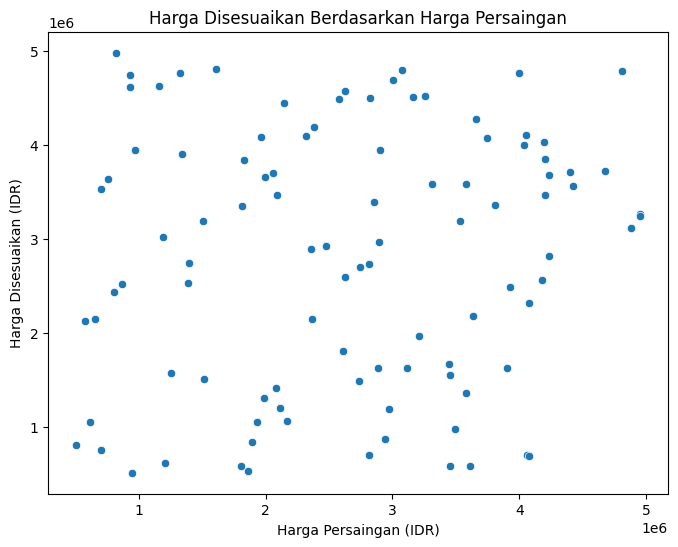

In [2]:

# Langkah 2: Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi harga dasar produk
plt.figure(figsize=(8, 6))
sns.histplot(dummy_df['Base Price (IDR)'], bins=20, kde=True)
plt.title('Distribusi Harga Dasar Produk UMKM')
plt.xlabel('Harga Dasar (IDR)')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi harga yang disesuaikan berdasarkan permintaan dan persaingan
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Competition Price (IDR)', y='Price Adjusted (IDR)', data=dummy_df)
plt.title('Harga Disesuaikan Berdasarkan Harga Persaingan')
plt.xlabel('Harga Persaingan (IDR)')
plt.ylabel('Harga Disesuaikan (IDR)')
plt.show()



### Langkah 3: Preprocessing Data
Pada langkah ini, kita akan melakukan enkoding pada variabel musim (peak/off-peak) menggunakan LabelEncoder dari scikit-learn. Ini diperlukan untuk mengubah variabel kategorikal menjadi numerik agar dapat digunakan dalam analisis model pembelajaran mesin.


In [3]:

# Langkah 3: Preprocessing Data
from sklearn.preprocessing import LabelEncoder

# Mengencode kategori musim (peak/off-peak)
label_encoder = LabelEncoder()
dummy_df['Season'] = label_encoder.fit_transform(dummy_df['Season'])

# Memeriksa data setelah preprocessing
dummy_df.head()


,Product ID,Product Name,Base Price (IDR),Demand,Stock,Competition Price (IDR),Season,Price Adjusted (IDR)
0,1,Product A,1.717402e+06,190,334,1.999437e+06,1,3.658251e+06
1,2,Product A,2.652996e+06,66,64,3.922925e+06,0,2.489884e+06
2,3,Product A,2.151400e+06,300,30,1.860566e+06,0,5.394543e+05
3,4,Product D,1.111863e+06,117,98,4.180358e+06,1,2.565483e+06
4,5,Product D,1.156333e+06,228,49,1.608732e+06,1,4.805271e+06



### Langkah 4: Normalisasi Data
Pada langkah ini, kita akan melakukan normalisasi pada data numerik seperti harga dasar, harga persaingan, dan stok produk agar berada pada skala yang sama. Normalisasi ini penting untuk memastikan bahwa semua fitur memiliki kontribusi yang setara dalam model yang akan dilatih.


In [4]:

# Langkah 4: Normalisasi Data
from sklearn.preprocessing import StandardScaler

# Melakukan normalisasi pada kolom harga dasar, harga persaingan, dan stok produk
scaler = StandardScaler()
dummy_df[['Base Price (IDR)', 'Competition Price (IDR)', 'Stock']] = scaler.fit_transform(dummy_df[['Base Price (IDR)', 'Competition Price (IDR)', 'Stock']])

# Memeriksa data setelah normalisasi
dummy_df.head()


,Product ID,Product Name,Base Price (IDR),Demand,Stock,Competition Price (IDR),Season,Price Adjusted (IDR)
0,1,Product A,-0.793267,190,0.835519,-0.531374,1,3.658251e+06
1,2,Product A,-0.019517,66,-1.098553,1.046279,0,2.489884e+06
2,3,Product A,-0.434344,300,-1.342103,-0.645277,0,5.394543e+05
3,4,Product D,-1.294056,117,-0.855003,1.257427,1,2.565483e+06
4,5,Product D,-1.257278,228,-1.206001,-0.851833,1,4.805271e+06



### Langkah 5: Membagi Data Train dan Test
Pada langkah ini, kita akan membagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi 80% untuk latih dan 20% untuk uji. Hal ini penting agar kita dapat melatih model pada data latih dan mengujinya dengan data uji yang tidak terlihat sebelumnya.


In [5]:

# Langkah 5: Membagi Data Train dan Test
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi fitur (X) dan target (y)
X = dummy_df[['Base Price (IDR)', 'Demand', 'Stock', 'Competition Price (IDR)', 'Season']]
y = dummy_df['Price Adjusted (IDR)']

# Membagi data menjadi data latih (train) dan data uji (test) dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran data train dan test
(X_train.shape, X_test.shape)


((80, 5), (20, 5))


### Langkah 6: Melatih Model
Pada langkah ini, kita akan menggunakan algoritma RandomForestRegressor untuk melatih model harga dinamis. Regresi digunakan di sini karena kita memprediksi harga yang bersifat kontinu. Model ini juga dapat membantu kita untuk mengetahui fitur mana yang paling berpengaruh dalam menentukan harga.


In [6]:

# Langkah 6: Melatih Model
from sklearn.ensemble import RandomForestRegressor

# Membuat dan melatih model RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Melihat fitur penting dari model
model.feature_importances_


array([0.20948243, 0.2093963 , 0.27961702, 0.26008061, 0.04142365])


### Langkah 7: Evaluasi Model
Pada langkah ini, kita akan mengevaluasi kinerja model dengan menggunakan data uji. Kita akan menghitung metrik evaluasi seperti Mean Absolute Error (MAE), Mean Squared Error (MSE), dan R-squared (R²) untuk menilai seberapa baik model memprediksi harga produk yang disesuaikan.


In [7]:

# Langkah 7: Evaluasi Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Memprediksi harga pada data uji
y_pred = model.predict(X_test)

# Menghitung error dan menampilkan laporan evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2


(1074244.7222430487, 1559407923576.86, 0.04799646309535732)


### Langkah 8: Prediksi
Pada langkah terakhir, kita akan menggunakan model yang telah dilatih untuk memprediksi harga produk yang disesuaikan berdasarkan data baru. Hal ini memungkinkan sistem harga dinamis untuk memberikan harga yang lebih akurat berdasarkan kondisi pasar yang berubah.


In [9]:
# Langkah 8: Prediksi
# Melakukan prediksi pada data baru (dummy)
new_data = pd.DataFrame({
    'Base Price (IDR)': [1000000], # Removing the nested list and transform
    'Demand': [200],
    'Stock': [50],
    'Competition Price (IDR)': [1200000], # Removing the nested list and transform
    'Season': [label_encoder.transform(['Peak'])[0]]
})

# Applying the scaler to the relevant columns in the new_data DataFrame
new_data[['Base Price (IDR)', 'Competition Price (IDR)', 'Stock']] = scaler.transform(new_data[['Base Price (IDR)', 'Competition Price (IDR)', 'Stock']])

# Memprediksi harga yang disesuaikan untuk data baru
prediction = model.predict(new_data)
prediction

array([3273863.71262378])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
